# Pengujian Ambang Baru dan Perbaikan Label Risiko

**Tanggal kegiatan: 22 Juli 2026**

Kemarin ditetapkan aturan pemilihan ambang: target recall 0,98 pada prediksi
out-of-fold data latih. Hari ini aturan itu diterapkan, lalu hasilnya diuji pada
data uji yang belum pernah dilihat model.

In [1]:
import warnings, sys
warnings.simplefilter("ignore")
sys.path.insert(0, "..")

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import joblib

from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn.metrics import (
    confusion_matrix, f1_score, fbeta_score, precision_score,
    recall_score, roc_auc_score,
)
from model.train import (
    load_dataset, FEATURE_ORDER, RANDOM_STATE, CV,
    _ordinal_encode_for_xgb, best_f1_threshold, recall_target_threshold, TARGET_RECALL,
)

plt.rcParams.update({"figure.dpi": 110, "font.size": 9})

df = load_dataset()
X, y = df[FEATURE_ORDER], df["stroke"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y
)
model = joblib.load("artifacts/stroke_risk_model.joblib")["model"]
Xtr_e, Xte_e = _ordinal_encode_for_xgb(X_train), _ordinal_encode_for_xgb(X_test)
proba = model.predict_proba(Xte_e)[:, 1]
tot = int(y_test.sum())
print(f"Data uji: {len(y_test):,} orang, {tot} di antaranya kena stroke")

Data uji: 1,533 orang, 75 di antaranya kena stroke


## 1. Ambang Baru Diterapkan

In [2]:
oof = cross_val_predict(model, Xtr_e, y_train, cv=CV, method="predict_proba")[:, 1]
yt = y_train.to_numpy()

th_baru = recall_target_threshold(yt, oof, TARGET_RECALL)
th_lama = best_f1_threshold(yt, oof)

print(f"  Ambang lama (F1 terbaik)      : {th_lama:.3f}")
print(f"  Ambang baru (target recall)   : {th_baru:.3f}")
print(f"  Target recall pada OOF        : {TARGET_RECALL}")
print(f"  Recall tercapai pada OOF      : {recall_score(yt, (oof >= th_baru).astype(int)):.3f}")

  Ambang lama (F1 terbaik)      : 0.705
  Ambang baru (target recall)   : 0.042
  Target recall pada OOF        : 0.98
  Recall tercapai pada OOF      : 0.983


## 2. Hasil di Data Uji

In [3]:
def ringkas(th):
    yp = (proba >= th).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, yp).ravel()
    return dict(th=th, tp=tp, fn=fn, fp=fp, tn=tn, recall=tp/tot,
                presisi=precision_score(y_test, yp, zero_division=0),
                f1=f1_score(y_test, yp), f2=fbeta_score(y_test, yp, beta=2),
                f3=fbeta_score(y_test, yp, beta=3))

lama, baru = ringkas(th_lama), ringkas(th_baru)

print(f"{'':24s}{'19 Juli':>12}{'22 Juli':>12}{'perubahan':>13}")
print("-" * 61)
baris = [("Ambang", "th", ".3f"), ("Penderita terdeteksi", "tp", "d"),
         ("Penderita terlewat", "fn", "d"), ("Salah positif", "fp", "d"),
         ("Orang sehat lolos", "tn", "d"), ("Recall", "recall", ".3f"),
         ("Presisi", "presisi", ".3f")]
for nm, k, f in baris:
    a, b = lama[k], baru[k]
    delta = f"{b-a:+.3f}" if f == ".3f" else f"{b-a:+d}"
    print(f"{nm:24s}{format(a,f):>12}{format(b,f):>12}{delta:>13}")

print()
print(f"BERHASIL. Penderita terdeteksi naik dari {lama['tp']} menjadi {baru['tp']} dari {tot}.")
print(f"Yang terlewat turun dari {lama['fn']} orang menjadi {baru['fn']} orang.")
print()
print(f"Harga yang dibayar: salah positif naik {lama['fp']} -> {baru['fp']}, ")
print(f"artinya {baru['fp']} dari {baru['tn']+baru['fp']} orang sehat "
      f"({100*baru['fp']/(baru['tn']+baru['fp']):.0f}%) ikut tertandai.")

                             19 Juli     22 Juli    perubahan
-------------------------------------------------------------
Ambang                         0.705       0.042       -0.663
Penderita terdeteksi              37          73          +36
Penderita terlewat                38           2          -36
Salah positif                    143         905         +762
Orang sehat lolos               1315         553         -762
Recall                         0.493       0.973       +0.480
Presisi                        0.206       0.075       -0.131

BERHASIL. Penderita terdeteksi naik dari 37 menjadi 73 dari 75.
Yang terlewat turun dari 38 orang menjadi 2 orang.

Harga yang dibayar: salah positif naik 143 -> 905, 
artinya 905 dari 1458 orang sehat (62%) ikut tertandai.


## 3. Masalah Baru yang Muncul

Setelah ambang diturunkan, label risiko yang tampil di aplikasi ikut bergeser.
Label sebelumnya dihitung dari ambang deteksi: batas "sedang" ditetapkan sebagai
setengah ambang deteksi. Aturan itu masuk akal ketika ambangnya masih 0,705,
tetapi menjadi kacau setelah ambangnya turun.

In [4]:
lama_batas_sedang = th_baru * 0.5
lvl_rusak = np.where(proba >= th_baru, "tinggi",
            np.where(proba >= lama_batas_sedang, "sedang", "rendah"))

print("KALAU LABEL MASIH DIHITUNG DARI AMBANG DETEKSI")
print(f"  batas tinggi = {th_baru:.3f}   batas sedang = {lama_batas_sedang:.3f}")
print()
for L in ["tinggi", "sedang", "rendah"]:
    m = lvl_rusak == L
    print(f"  {L:7s}: {m.sum():5d} orang ({100*m.mean():5.1f}%)")
print()
print("MASALAH: tidak seorang pun memperoleh label rendah, dan mayoritas")
print("pengguna langsung berlabel risiko tinggi. Label seperti ini tidak")
print("memberi informasi apa pun kepada keluarga yang memantau.")

KALAU LABEL MASIH DIHITUNG DARI AMBANG DETEKSI
  batas tinggi = 0.042   batas sedang = 0.021

  tinggi :   978 orang ( 63.8%)
  sedang :   555 orang ( 36.2%)
  rendah :     0 orang (  0.0%)

MASALAH: tidak seorang pun memperoleh label rendah, dan mayoritas
pengguna langsung berlabel risiko tinggi. Label seperti ini tidak
memberi informasi apa pun kepada keluarga yang memantau.


## 4. Perbaikan: Dua Ambang dengan Fungsi Berbeda

Akar masalahnya, satu angka dipakai untuk dua keperluan yang berbeda. Keduanya
dipisah:

- **Ambang deteksi 0,042** - menentukan siapa yang perlu pemeriksaan lanjutan
- **Ambang risiko tinggi 0,705** - menentukan label yang tampil di aplikasi

In [5]:
lvl = np.where(proba >= th_lama, "tinggi",
      np.where(proba >= th_baru, "sedang", "rendah"))

print("SETELAH DUA AMBANG DIPISAH")
print(f"  ambang deteksi = {th_baru:.3f}   ambang risiko tinggi = {th_lama:.3f}")
print()
print(f"{'label':9s}{'orang':>8}{'persen':>9}{'penderita':>11}")
print("-" * 38)
for L in ["tinggi", "sedang", "rendah"]:
    m = lvl == L
    print(f"{L:9s}{m.sum():>8}{100*m.mean():>8.1f}%{int(y_test[m].sum()):>11}")
print()
print("Sebaran kembali wajar. Notifikasi mendesak cukup untuk kelompok tinggi")
print("(11,7%), sedangkan kelompok sedang menerima ringkasan berkala tanpa alarm.")
print("Pemisahan ini juga mencegah kelelahan peringatan pada pengguna.")

SETELAH DUA AMBANG DIPISAH
  ambang deteksi = 0.042   ambang risiko tinggi = 0.705

label       orang   persen  penderita
--------------------------------------
tinggi        180    11.7%         37
sedang        798    52.1%         36
rendah        555    36.2%          2

Sebaran kembali wajar. Notifikasi mendesak cukup untuk kelompok tinggi
(11,7%), sedangkan kelompok sedang menerima ringkasan berkala tanpa alarm.
Pemisahan ini juga mencegah kelelahan peringatan pada pengguna.


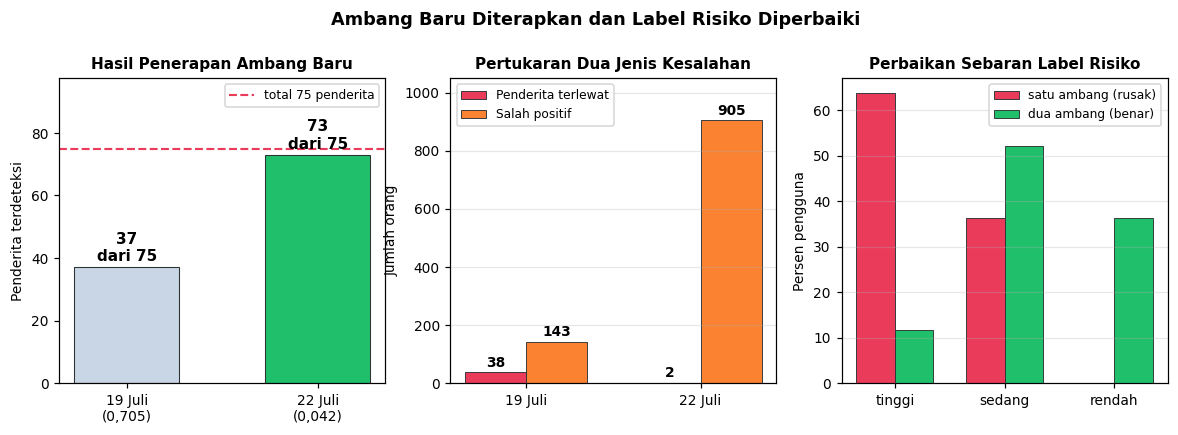

In [6]:
fig, ax = plt.subplots(1, 3, figsize=(13, 3.6))

b = ax[0].bar(["19 Juli\n(0,705)", "22 Juli\n(0,042)"], [lama["tp"], baru["tp"]],
              color=["#c8d6e5", "#20bf6b"], edgecolor="#2d3436", linewidth=.7, width=.55)
for rect, v in zip(b, [lama["tp"], baru["tp"]]):
    ax[0].text(rect.get_x()+rect.get_width()/2, v+2, f"{v}\ndari {tot}",
               ha="center", fontsize=10, fontweight="bold")
ax[0].axhline(tot, color="#eb3b5a", ls="--", lw=1.4, label=f"total {tot} penderita")
ax[0].set_ylim(0, tot*1.3); ax[0].set_ylabel("Penderita terdeteksi")
ax[0].set_title("Hasil Penerapan Ambang Baru", fontsize=10, fontweight="bold")
ax[0].legend(fontsize=8)

xp = np.arange(2); w = .35
ax[1].bar(xp-w/2, [lama["fn"], baru["fn"]], w, label="Penderita terlewat",
          color="#eb3b5a", edgecolor="#2d3436", linewidth=.6)
ax[1].bar(xp+w/2, [lama["fp"], baru["fp"]], w, label="Salah positif",
          color="#fa8231", edgecolor="#2d3436", linewidth=.6)
for i, (a_, b_) in enumerate([(lama["fn"], lama["fp"]), (baru["fn"], baru["fp"])]):
    ax[1].text(i-w/2, a_+18, str(a_), ha="center", fontsize=9, fontweight="bold")
    ax[1].text(i+w/2, b_+18, str(b_), ha="center", fontsize=9, fontweight="bold")
ax[1].set_xticks(xp, ["19 Juli", "22 Juli"]); ax[1].set_ylim(0, 1050)
ax[1].set_ylabel("Jumlah orang")
ax[1].set_title("Pertukaran Dua Jenis Kesalahan", fontsize=10, fontweight="bold")
ax[1].legend(fontsize=8); ax[1].grid(axis="y", alpha=.3)

kat = ["tinggi", "sedang", "rendah"]
rusak = [100*(lvl_rusak == k).mean() for k in kat]
benar = [100*(lvl == k).mean() for k in kat]
xp2 = np.arange(3)
ax[2].bar(xp2-w/2, rusak, w, label="satu ambang (rusak)", color="#eb3b5a",
          edgecolor="#2d3436", linewidth=.6)
ax[2].bar(xp2+w/2, benar, w, label="dua ambang (benar)", color="#20bf6b",
          edgecolor="#2d3436", linewidth=.6)
ax[2].set_xticks(xp2, kat); ax[2].set_ylabel("Persen pengguna")
ax[2].set_title("Perbaikan Sebaran Label Risiko", fontsize=10, fontweight="bold")
ax[2].legend(fontsize=8); ax[2].grid(axis="y", alpha=.3)

fig.suptitle("Ambang Baru Diterapkan dan Label Risiko Diperbaiki",
             fontsize=11.5, fontweight="bold", y=1.05)
plt.show()

## 5. Catatan Penting soal Pembenaran

Sempat dipertimbangkan memakai F2-score sebagai pembenaran, karena F2 memberi
bobot recall dua kali lipat presisi. Setelah dihitung, ternyata **F2 justru masih
memenangkan ambang lama**.

In [7]:
print(f"{'metrik':8s}{'ambang lama':>14}{'ambang baru':>14}  pemenang")
print("-" * 50)
for nm, k in [("F1", "f1"), ("F2", "f2"), ("F3", "f3")]:
    menang = "ambang lama" if lama[k] > baru[k] else "ambang baru"
    print(f"{nm:8s}{lama[k]:>14.3f}{baru[k]:>14.3f}  {menang}")
print()
print("Karena presisi terlalu rendah, bobot recall 2x belum cukup membalikkan")
print("hasilnya. Baru pada F3 ambang baru unggul.")
print()
print("Maka pembenaran revisi ini TIDAK bersandar pada metrik gabungan, melainkan")
print("pada pertimbangan klinis: pada stroke, biaya melewatkan penderita jauh")
print("lebih besar daripada biaya satu kali pemeriksaan tambahan.")

metrik     ambang lama   ambang baru  pemenang
--------------------------------------------------
F1               0.290         0.139  ambang lama
F2               0.385         0.286  ambang lama
F3               0.433         0.442  ambang baru

Karena presisi terlalu rendah, bobot recall 2x belum cukup membalikkan
hasilnya. Baru pada F3 ambang baru unggul.

Maka pembenaran revisi ini TIDAK bersandar pada metrik gabungan, melainkan
pada pertimbangan klinis: pada stroke, biaya melewatkan penderita jauh
lebih besar daripada biaya satu kali pemeriksaan tambahan.


## 6. Kesimpulan

Ambang deteksi diturunkan dari 0,705 menjadi 0,042 memakai aturan target recall
0,98 pada prediksi out-of-fold. Hasilnya di data uji: **73 dari 75 penderita
terdeteksi (recall 0,973)**, naik dari 37. Penderita yang terlewat turun dari 38
menjadi 2.

Harga yang dibayar: salah positif naik dari 143 menjadi 905, presisi turun dari
0,206 menjadi 0,075. Rasio ini dapat dipertahankan karena ANTARAGA berperan
sebagai penyaring tahap awal yang memicu pemeriksaan lanjutan, bukan alat
diagnosis. Sebagai pembanding, skor klinis ABCD² yang dirujuk pedoman AHA bekerja
pada titik serupa: sensitivitas 0,89 dengan PPV 0,08.

Label risiko di aplikasi memakai ambang terpisah agar tetap bermakna: 11,7%
pengguna berlabel tinggi, 52,1% sedang, dan 36,2% rendah.